# Adversarial and Privacy Reinforced Credit Card Fraud Detection on MLP

**Names : Charline HUANGFU, Alexandre MARTEL**

This project aims to develop a trustworthy machine learning pipeline for Credit Card Fraud Detection. In the financial sector, a model's value is not only measured by its accuracy but also by its resilience to attacks, its respect for data privacy, and its ethical fairness.

Throughout this notebook, we implement and evaluate a Multi-Layer Perceptron (MLP) across three critical dimensions:


1.   **Adversarial Robustness:** We simulate evasion attempts using the **Fast Gradient Sign Method (FGSM)** and defend the model through **Adversarial Training**.
2.   **Data Privacy:** We assess the risk of data leakage via **Membership Inference Attacks (MIA)** and implement **Differential Privacy (DP-SGD)** as a defense mechanism.
3. **Fairness & Bias:** We analyze potential biases regarding transaction amounts and apply **Reweighing** techniques to ensure equitable model performance.



This notebook is a recap of all our experiments. While the core logic, model architectures and experimental scripts are modularized within the `src` directory for better maintainability, this notebook is used to visualize and analyze the results.

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display
import os

In [ ]:
# git clone https://github.com/alexandre-martel/adversarial-privacy-fraud-detection.git

In [2]:
!pip install -r requirements.txt

In [97]:
!python -m src.utils -d

Downloaded to : C:\Users\charl\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3
File copied to : data\creditcard.csv


## Dataset Exploratory Analysis

We will use the Credit Card Fraud Detection dataset from Kaggle, which contains transactions made by European cardholders in September 2013.

The dataset consists primarily of numerical features derived from a Principal Component Analysis (PCA) transformation. Due to confidentiality constraints, the original features and specific domain background are unavailable. Consequently, features V1 through V28 represent the principal components, while 'Time' and 'Amount' are the only variables retained in their original, non-transformed state.


In [98]:
df = pd.read_csv("data/creditcard.csv")

In [10]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [99]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


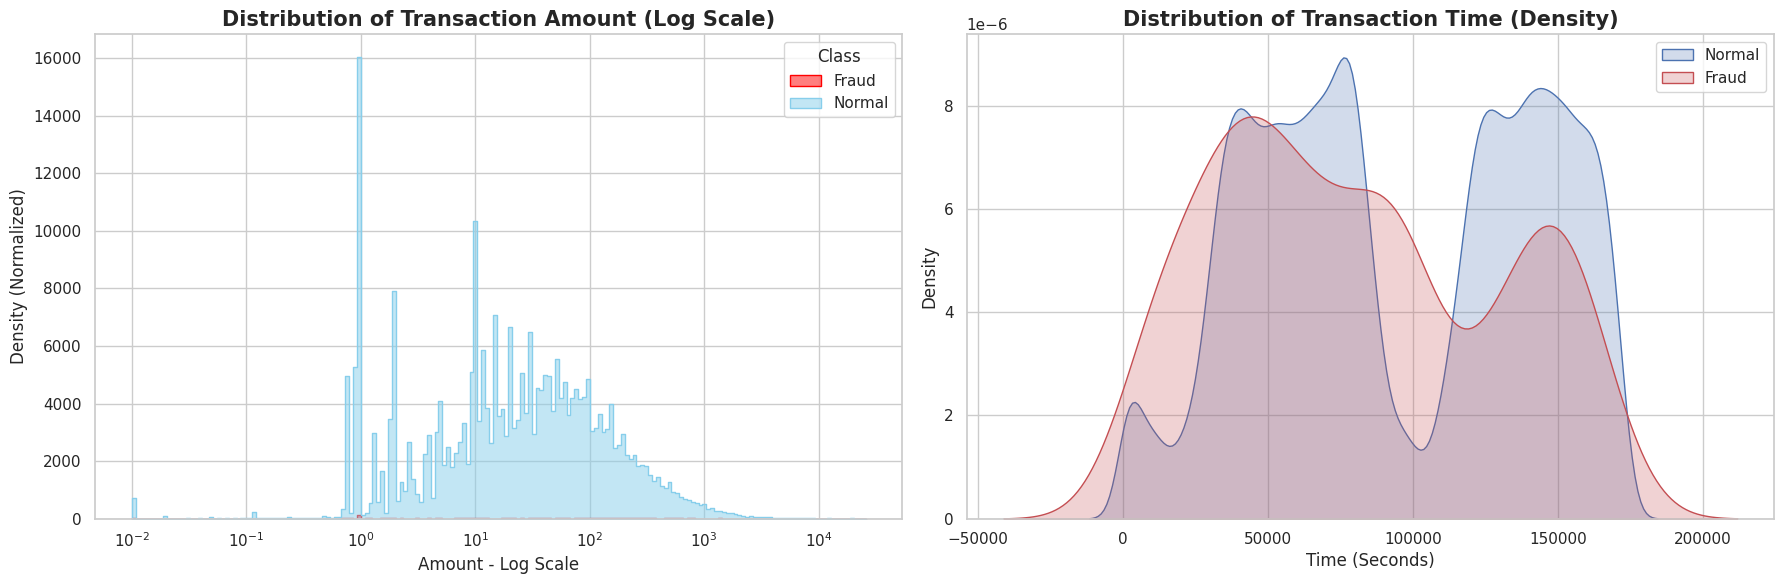

In [23]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(data=df, x='Amount', hue='Class', element="step", common_norm=False,
             palette={0: 'skyblue', 1: 'red'}, alpha=0.5, ax=ax[0], log_scale=True)

ax[0].set_title('Distribution of Transaction Amount (Log Scale)', fontsize=15, fontweight='bold')
ax[0].set_xlabel('Amount - Log Scale')
ax[0].set_ylabel('Density (Normalized)')
ax[0].legend(title='Class', labels=['Fraud', 'Normal'])

sns.kdeplot(data=df[df['Class'] == 0]['Time'], label='Normal', color='b', fill=True, ax=ax[1])
sns.kdeplot(data=df[df['Class'] == 1]['Time'], label='Fraud', color='r', fill=True, ax=ax[1])

ax[1].set_title('Distribution of Transaction Time (Density)', fontsize=15, fontweight='bold')
ax[1].set_xlabel('Time (Seconds)')
ax[1].set_ylabel('Density')
ax[1].legend()

plt.tight_layout()
plt.show()

No Frauds: 284315 (99.83% of the dataset)
Frauds: 492 (0.17% of the dataset)


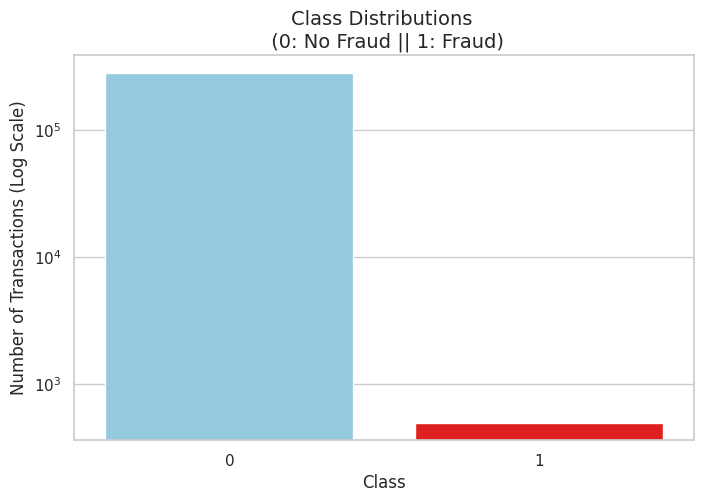

In [32]:
counts = df['Class'].value_counts()
n_total = len(df)
print(f"No Frauds: {counts[0]} ({round(counts[0]/n_total * 100, 2)}% of the dataset)")
print(f"Frauds: {counts[1]} ({round(counts[1]/n_total * 100, 2)}% of the dataset)")

plot_df = counts.reset_index()
plot_df.columns = ['Class', 'Count']

plt.figure(figsize=(8, 5))
sns.barplot(
    data=plot_df,
    x='Class',
    y='Count',
    hue='Class',
    palette={0: "skyblue", 1: "red"},
    legend=False
)

plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Transactions (Log Scale)')
plt.yscale('log')

plt.show()

The Preliminary Exploratory Data Analysis reveals a severe class imbalance within the dataset: only 492 transactions (0.17%) are identified as fraudulent out of a total of 284 807.

This extreme imbalance is the core technical challenge of the project  :      
- **Adversarial:** The decision boundary for the "Fraud" class is extremely fragile. Because the model sees so few examples, a tiny perturbation (FGSM) can easily "push" a fraud sample into the "Normal" zone.
- **Privacy:** Rare samples are unique fingerprints. In a dataset of 284k, the 492 frauds are outliers. This makes them much easier for an attacker to identify via Membership Inference, as the model overfits more easily on rare data.
- **Bias:** It creates a Majority Class Bias. Without mitigation, the model will simply predict "Normal" for everything to achieve 99.8% accuracy, completely failing its purpose.

## Data Pipeline

Before feeding the data into our neural network, we need to load, split, and clean it properly. Since we are dealing with a highly imbalanced financial dataset, careful preprocessing is critical. Here is how our data pipeline, found in `utils.py` , works step-by-step:

1. Downloading & Loading (`download_creditcard_dataset` & `load_dataset`): We automate the download of the dataset directly from Kaggle. The script reads the CSV file, separates the features (X) from the target label (y - where 1 is Fraud and 0 is Normal) and stores the feature names.
   
2. Stratified Splitting (`get_datasets`): We split the data into three distinct sets: Train (60%), Validation (20%), and Test (20%).We use stratification (stratify=y). Because frauds are extremely rare (only ~0.17%), stratification guarantees that this exact same ratio of frauds is preserved across all three sets.
   
3. Standardization without Data Leakage (`standardize`): Neural networks work best when input features are on the same scale. We use StandardScaler to center the data around 0. To strictly prevent data leakage, the scaler only "learns" the mean and variance from the Training set, and then simply applies that transformation to the Validation and Test sets.
   
4. Adversarial Attack Boundaries : During the scaling step, we also compute the 0.5% and 99.5% quantiles of the training data. Later in the project, when we generate fake "adversarial" transactions to attack the model, we will use these limits to "clip" the fake data. This ensures our simulated attacks look like realistic banking transactions rather than impossible mathematical anomalies.
   
5. Handling Class Imbalance (`compute_scale_pos_weight`): To prevent the model from ignoring the rare fraud cases, we calculate the exact ratio of normal transactions to fraudulent ones. This weight will be passed to our Loss Function later to penalize the model heavily if it misses a fraud.
   
6. Reproducibility (`set_seed`): By locking the random seeds (Seed = 9) across Python, NumPy, and PyTorch, we guarantee that the data splits, model weights initialization, and final results will be exactly the same every time we run this notebook.

## Baseline MLP

For this project, we implement a Multi-Layer Perceptron (MLP) as our core architecture. An MLP is a classic "feed-forward" neural network consisting of an input layer, several hidden layers with non-linear activation functions (like ReLU), and an output layer.

We chose an MLP because it is generally more effective than CNNs or RNNs for tabular data, where features do not have a fixed spatial or sequential relationship. Moreover fraud patterns are rarely simple : a criminal might exploit specific, multi-dimensional combinations of time, location and transaction amount. While a simple model like Logistic Regression might fail to see these patterns, an MLP can learn these complex, non-linear relationships.

Another critical advantage is that MLPs are fully differentiable. This property is a prerequisite for our research, as it allows us to compute the gradients required to generate adversarial attacks (like FGSM) and to implement Differential Privacy (via DP-SGD), both of which rely on manipulating the model's internal gradients during or after training.

The baseline experiment serves as our primary benchmark, where we train a standard MLP to establish a performance reference on the raw credit card fraud dataset. Because this dataset is characterized by an extreme class imbalance, we prioritize the Precision-Recall Area Under the Curve (PR-AUC) and Recall as our core evaluation metrics instead of accuracy. We focus on PR-AUC because it provides a much more reliable measure of the model's ability to identify rare fraud cases without being influenced by the overwhelming number of legitimate transactions. Furthermore, a high Recall is essential for financial institutions, as the cost of a missed fraud is significantly higher than the cost of a false alert. To achieve this, we employ a weighted loss function that forces the MLP to learn the complex, non-linear patterns of fraudulent behavior more effectively.

In [5]:
!python -m src.baselines.baseline_mlp 

Epoch 01 | train loss: 0.55986 | val PR-AUC: 0.7684
Epoch 02 | train loss: 0.30587 | val PR-AUC: 0.7738
Epoch 03 | train loss: 0.26980 | val PR-AUC: 0.7859
Epoch 04 | train loss: 0.22689 | val PR-AUC: 0.7955
Epoch 05 | train loss: 0.18451 | val PR-AUC: 0.7967
Epoch 06 | train loss: 0.20191 | val PR-AUC: 0.8124
Epoch 07 | train loss: 0.14704 | val PR-AUC: 0.8138
Epoch 08 | train loss: 0.14037 | val PR-AUC: 0.8138
Epoch 09 | train loss: 0.12568 | val PR-AUC: 0.8145
Epoch 10 | train loss: 0.11106 | val PR-AUC: 0.8104

=== Baseline MLP - Validation ===
Accuracy             : 0.9796179909413293
Precision (weighted) : 0.9982267001425034
Recall (weighted)    : 0.9796179909413293
F1-score (weighted)  : 0.9882008191201307
Precision (macro)    : 0.5361511231103759
Recall (macro)       : 0.9444158447816362
F1-score (macro)     : 0.5619578980864647
ROC-AUC              : 0.9804511534634814
PR-AUC (pos)         : 0.8104002746575198

Classification report:
               precision    recall  f1-scor

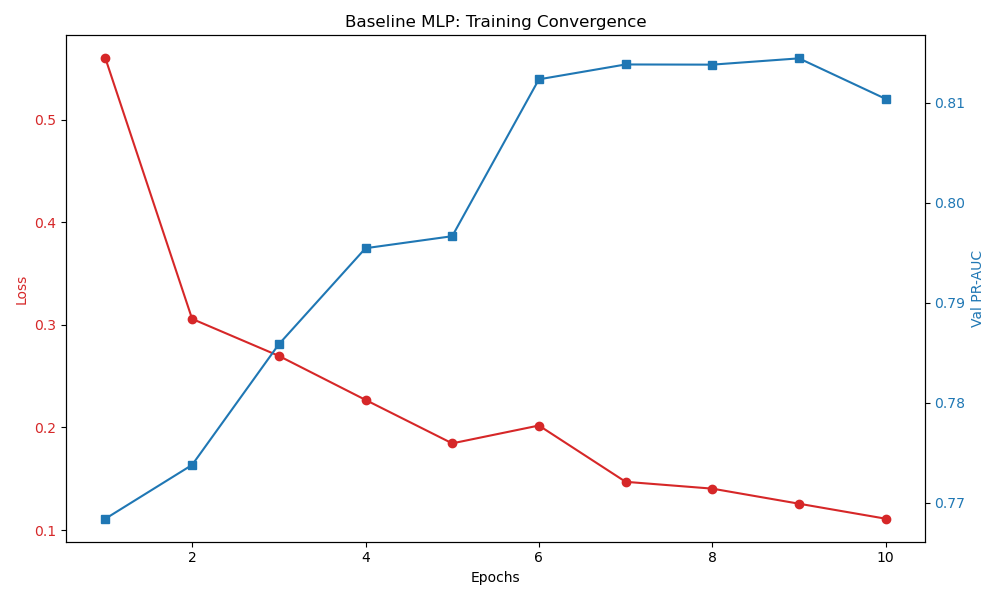

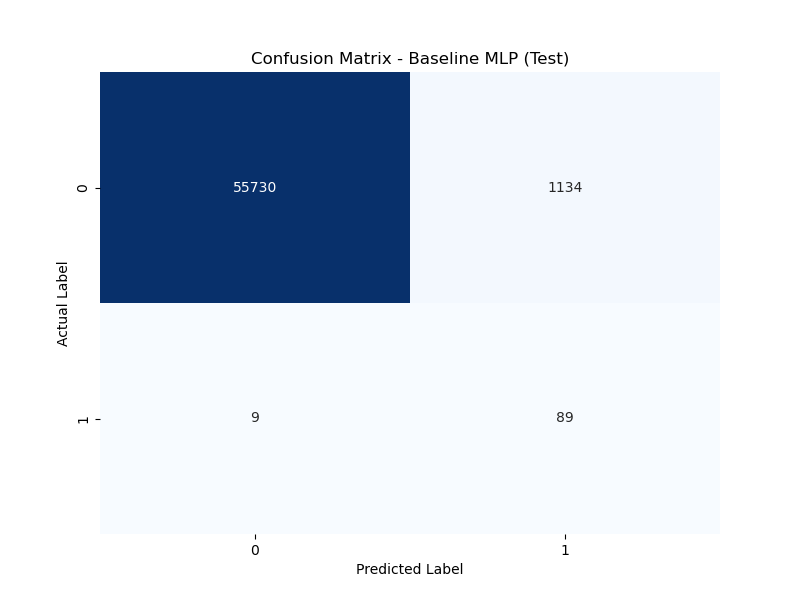

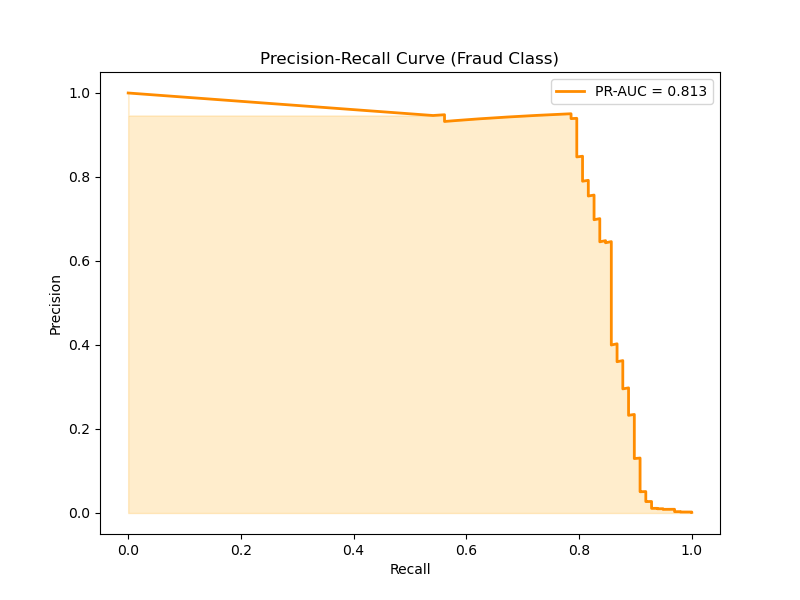

In [30]:
display(Image(filename='/results/baseline_model/learning_curves.png'))
display(Image(filename='/results/baseline_model/confusion_matrix.png'))
display(Image(filename='/results/baseline_model/pr_curve.png'))

The baseline MLP model demonstrates a successful convergence, with the training loss steadily decreasing to 0.11 while maintaining a stable validation PR-AUC of approximately 0.81. The evaluation on the test set confirms a robust generalization, yielding a PR-AUC of 0.813 and a high Recall of 91%, which is critical for minimizing undetected financial fraud. While the overall accuracy appears high at 97.9%, this metric is largely driven by the majority class. The true effectiveness is reflected in the model's ability to identify 89 out of 98 actual frauds. The observed low precision (7%) and the resulting 1,134 false positives are a direct and expected consequence of our cost-sensitive learning approach—utilizing a high `pos_weight` to prioritize security over precision. This establishes a highly sensitive baseline that, while effective at catching fraud, remains potentially vulnerable to adversarial perturbations and privacy leaks, justifying the subsequent security and privacy audits.

## Adversarial Robustness (Security)

In this section, we test the security of our baseline model. Even if a model has a high PR-AUC, it can still be vulnerable to Adversarial Attacks. These are small, intentional perturbations added to the input data designed to trick the model into making a mistake.

### The Attack : Fast Gradient Sign Method (FGSM)

The Fast Gradient Sign Method (FGSM) is a popular attack that uses the model's own "knowledge" (its gradients) against it. 

Instead of using gradients to decrease the loss (like we do during training), FGSM uses gradients to increase the loss. By moving the input data in the direction that maximizes the error, the attacker can force the model to misclassify a fraudulent transaction as "normal."

1. We calculate how much the loss changes for a specific transaction.
2. Ze take the `sign` of that gradient.
3. We multiply this direction by a small value called $\epsilon$. This is the "budget" or "strength" of the attack.
4. $x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y))$

In a real-world banking scenario, an attacker cannot provide "impossible" values (like a negative transaction amount or a value 1000x higher than any real customer). To keep our attack realistic, we use the 0.5% and 99.5% quantiles we calculated earlier to "clip" the noisy data, ensuring the adversarial samples still look like plausible transactions.

In [9]:
!python -m src.adversarial.fsgm_attack --with_epsilon_study

--- Evaluation before FGSM---

=== MLP - Test (avant attaque) ===
Accuracy             : 0.9799339910817738
Precision (weighted) : 0.9982435657685566
Recall (weighted)    : 0.9799339910817738
F1-score (weighted)  : 0.9883781358665298
Precision (macro)    : 0.536305202804151
Recall (macro)       : 0.9441104733958863
F1-score (macro)     : 0.5622978488874545
ROC-AUC              : 0.9718694191942393
PR-AUC (pos)         : 0.8131557834538906

Classification report:
               precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     56864
         1.0       0.07      0.91      0.13        98

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962

Confusion matrix:
 [[55730  1134]
 [    9    89]]
--- Detailed Audit for Epsilon = 0.1 ---

=== MLP - Test (FGSM, eps=0.1) ===
Accuracy             : 0.9337804150135178
Precision (weighted) : 0.99811170719

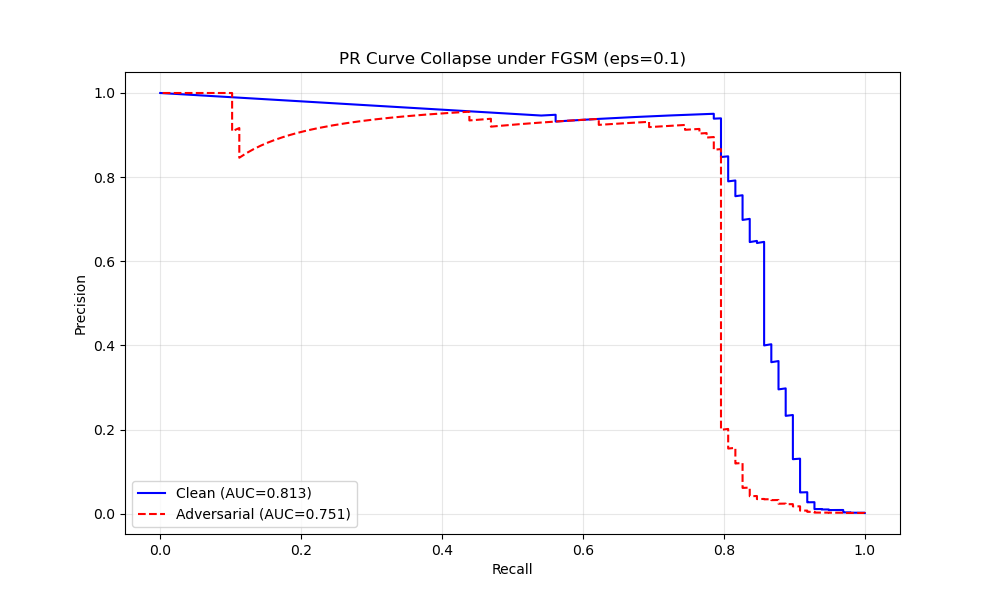

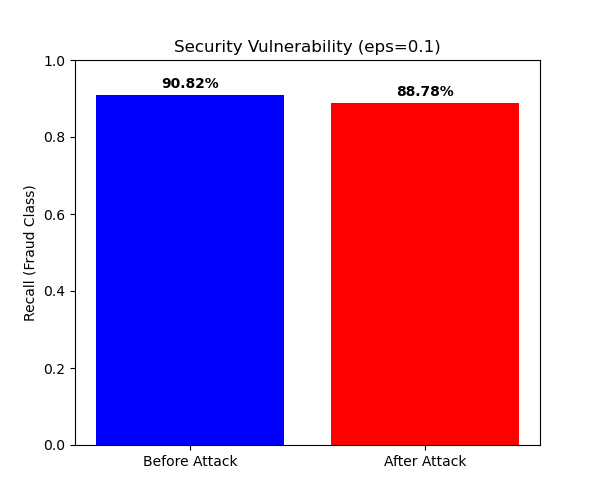

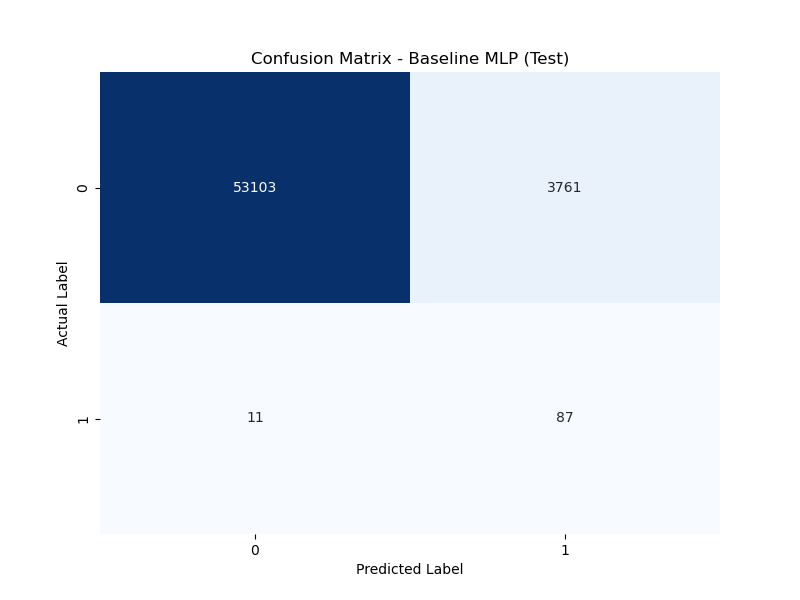

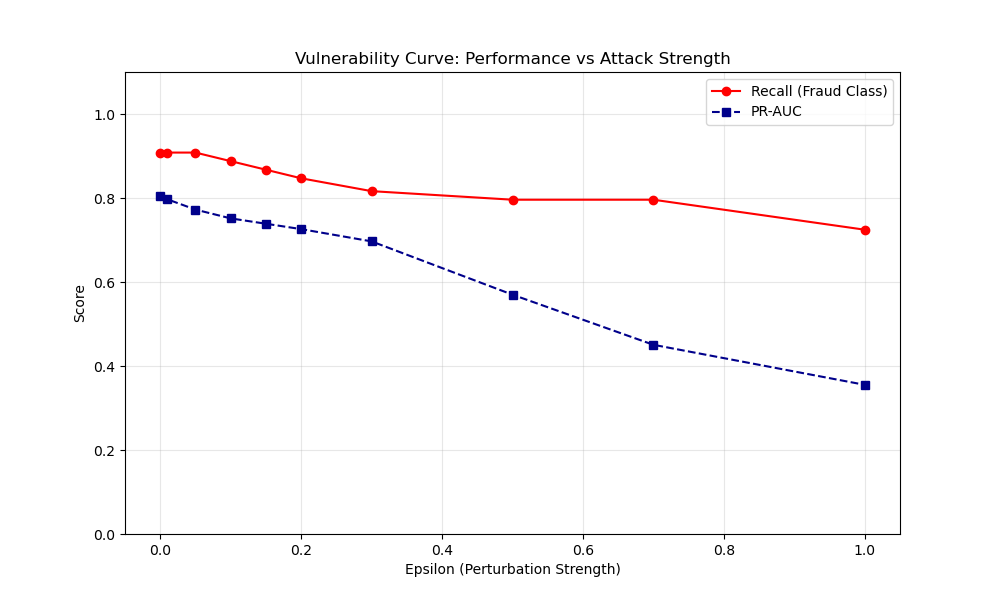

In [29]:
display(Image(filename='results/fgsm_attack/attack_pr_comparison.png'))
display(Image(filename='results/fgsm_attack/recall_drop.png'))
display(Image(filename='results/fgsm_attack/confusion_matrix_adv_eps_0.1.png'))
display(Image(filename='results/fgsm_attack/epsilon_study.png'))

The adversarial attack reveals a significant vulnerability in our baseline MLP. While the Recall remains relatively high for due to the model's cost-sensitive bias, the PR-AUC collapses from 0.81 to 0.35 under strong perturbations ($\epsilon=1.0$).

Specifically, at $\epsilon=0.1$, we observe a tripling of False Positives (from 1134 to 3761), demonstrating that the FGSM attack effectively neutralizes the model's utility by overwhelming the system with false alerts. This "denial-of-service" effect on the manual review process justifies the need for Adversarial Training to stabilize the decision boundaries.

### The Defense : Advertial Traning

To defend our system against the vulnerabilities identified in the previous audit, we implement Adversarial Training, a proactive defense strategy where the model practices handling malicious data during its learning phase. In this script, we modify the standard training loop by introducing a mixed-batch approach through the `train_epoch_mixed` function. For every training step, the model generates a set of adversarial examples using the FGSM attack and combines them with original, clean transactions based on a specific mix-ratio. By constantly exposing the neural network to these hard examples, we force it to smooth its decision boundaries and ignore the small mathematical perturbations that previously caused it to fail. This process creates a more robust version of our MLP that remains reliable even when a fraudster intentionally tries to bypass the security filters, though it often results in a slight trade-off where performance on clean data may decrease slightly in exchange for significantly higher security.

In [42]:
!python -m src.adversarial.adversarial_training --with_epsilon_study

Epoch 01 | train loss: 0.57868 | val PR-AUC: 0.6765
Epoch 02 | train loss: 0.36222 | val PR-AUC: 0.6808
Epoch 03 | train loss: 0.32364 | val PR-AUC: 0.6939
Epoch 04 | train loss: 0.29614 | val PR-AUC: 0.6809
Epoch 05 | train loss: 0.25667 | val PR-AUC: 0.6994
Epoch 06 | train loss: 0.26675 | val PR-AUC: 0.6969
Epoch 07 | train loss: 0.18687 | val PR-AUC: 0.6998
Epoch 08 | train loss: 0.28575 | val PR-AUC: 0.7017
Epoch 09 | train loss: 0.22534 | val PR-AUC: 0.6919
Epoch 10 | train loss: 0.23193 | val PR-AUC: 0.6883

=== Adversarial MLP - clean Test ===
Accuracy             : 0.9765106562269583
Precision (weighted) : 0.9982067538827276
Recall (weighted)    : 0.9765106562269583
F1-score (weighted)  : 0.9865971762986705
Precision (macro)    : 0.5309834308450206
Recall (macro)       : 0.9373026081563746
F1-score (macro)     : 0.5521727465636094
ROC-AUC              : 0.9744364103970232
PR-AUC (pos)         : 0.7038159510427513

Classification report:
               precision    recall  f1-s

adv_confusion_matrix.png


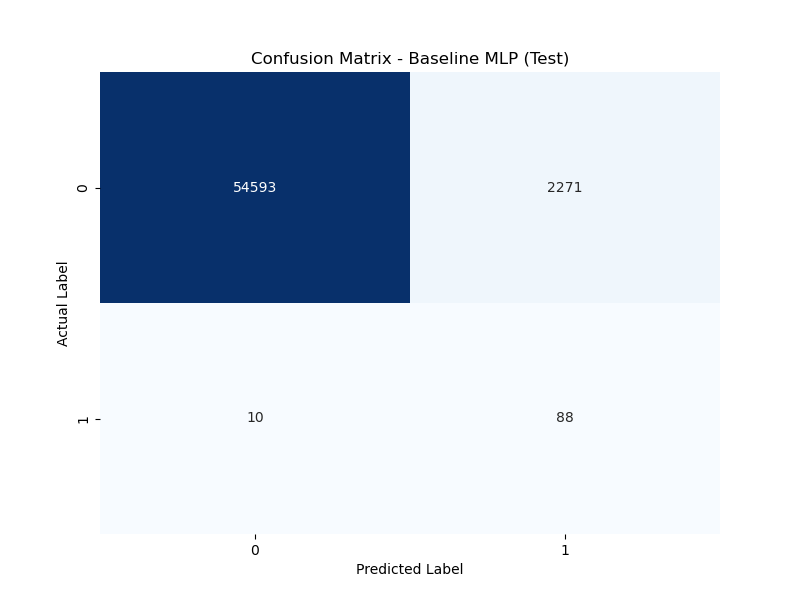

adv_pr_curve.png


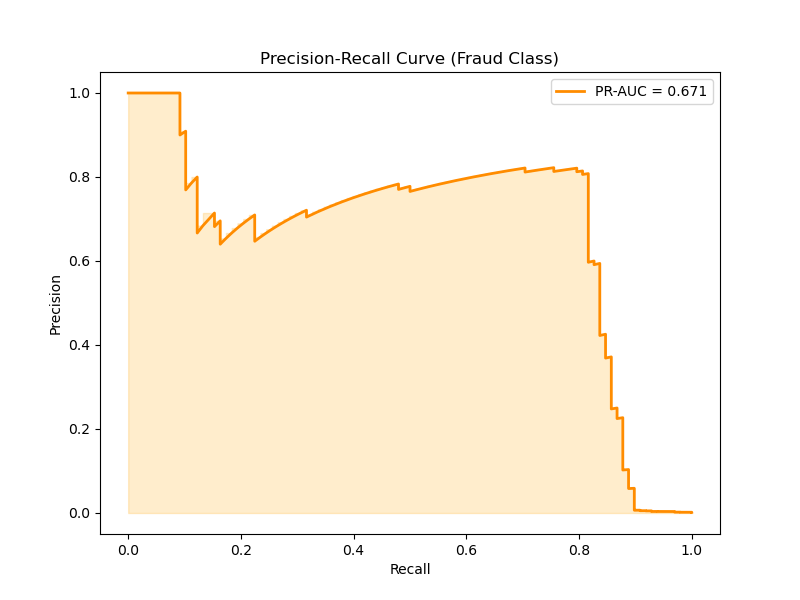

clean_confusion_matrix.png


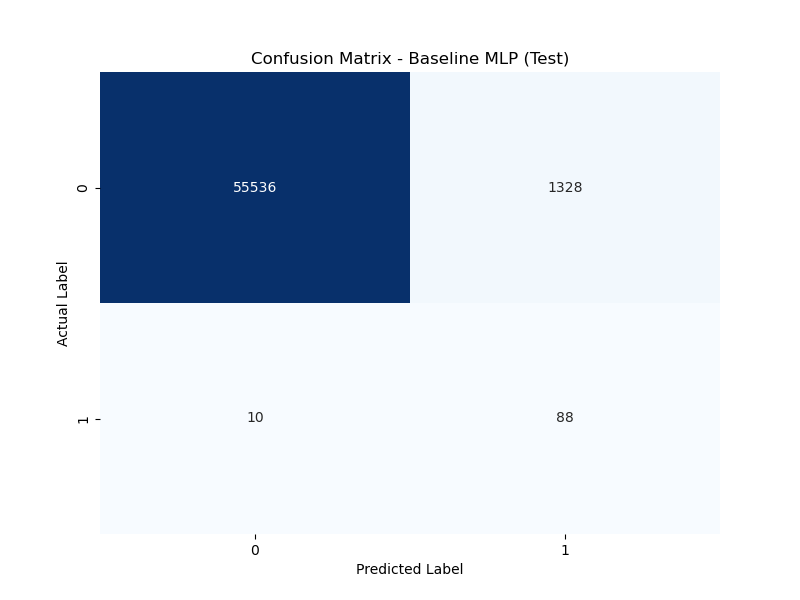

clean_pr_curve.png


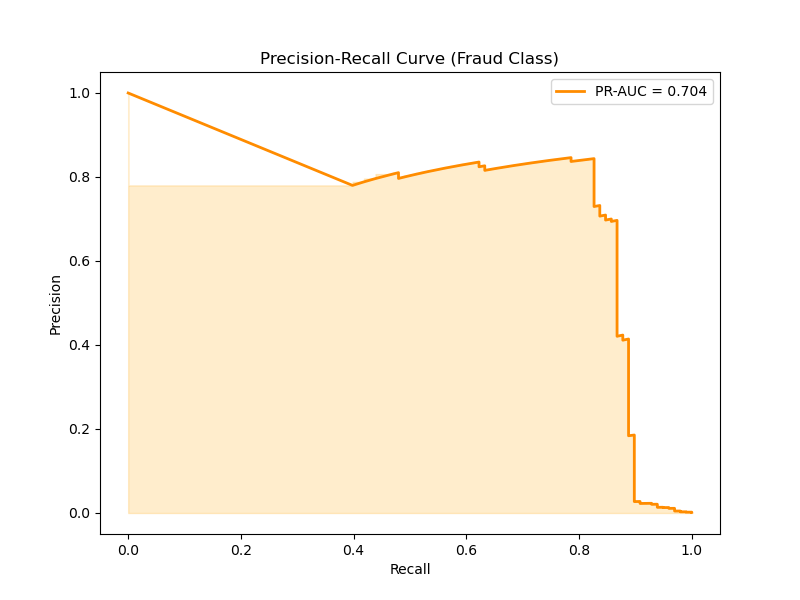

epsilon_study.png


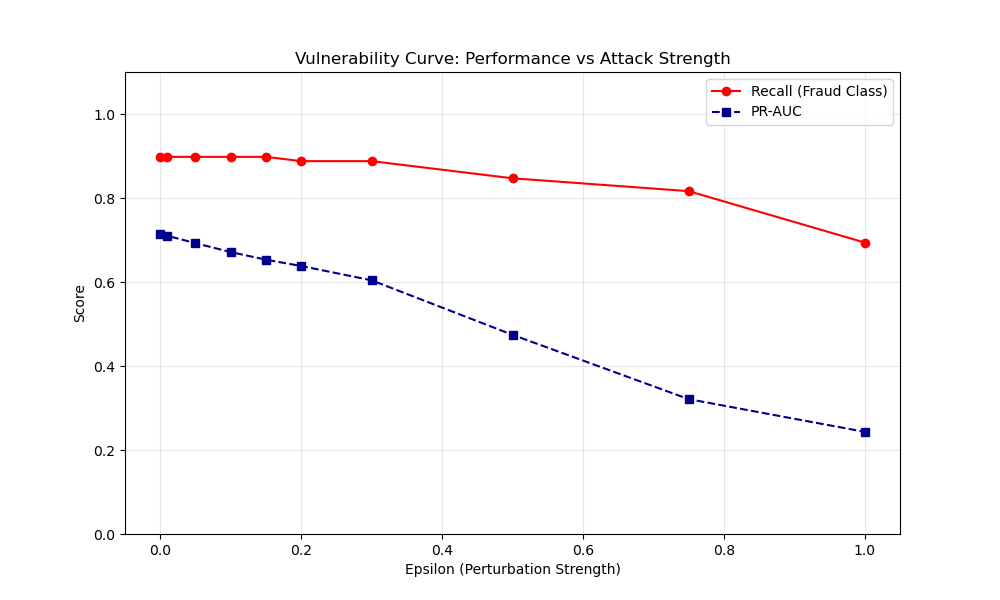

learning_curves.png


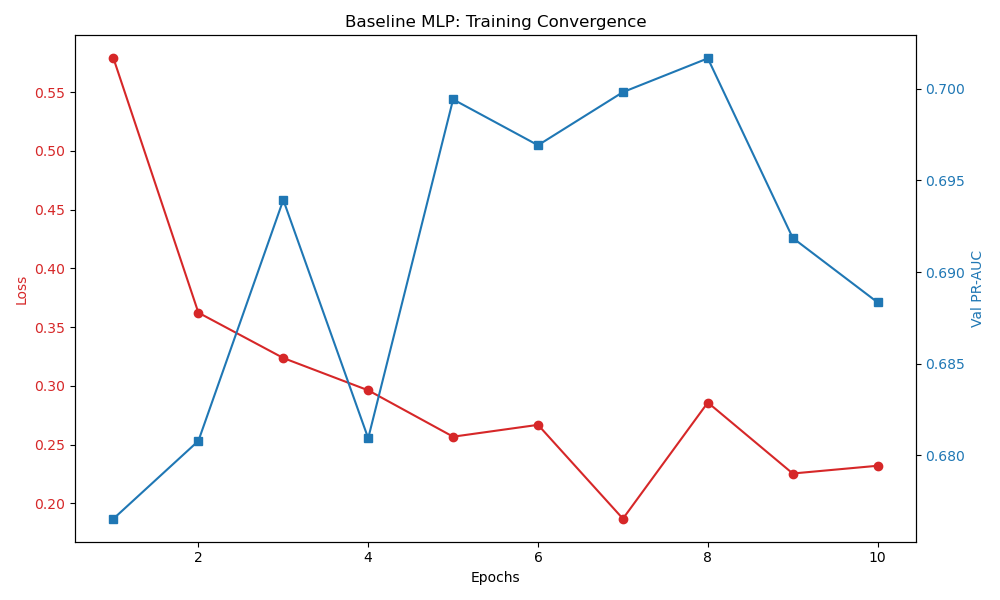

In [ ]:
for file in os.listdir("results/adversarial_model"):
    if file.endswith(".png"):
        print(f"{file}")
        display(Image(filename=os.path.join("results", "adversarial_model", file)))

The adversarial training effectively fortified the model, significantly reducing its sensitivity to malicious noise compared to the baseline. While the baseline MLP saw a massive surge in false positives (over 3,700 alerts) under a 0.1 epsilon attack, the adversarial model maintained much cleaner results with 40% fewer false alarms.

However, this robustness requires a performance tax on clean data, illustrating the classic trade-off in trustworthy machine learning. To gain this security, the model’s clean PR-AUC decreased from 0.81 to 0.70. By forcing the network to learn noisy patterns, we sacrifice the high-precision shortcuts that the baseline model uses to distinguish fraud in a perfect environment. While the model is now slightly less precise on normal daily transactions, this is a vital investment for financial safety; it prevents the total collapse of the detection system during a real-world evasion attempt.


## Privacy Protection (Confidentiality)

Now that we have secured our model against evasion attacks, we must address a different kind of threat: Privacy Leakage. Even if a model is robust and accurate, it might "leak" information about the specific individuals used to train it.

### The Attack: Membership Inference Attack (MIA)

A Membership Inference Attack (MIA) is a technique where an attacker tries to determine if a specific data record (e.g., a specific customer’s transaction) was part of the model's training set. If the attacker can look at the model's output and say with high confidence, "This transaction was used to train this model," it constitutes a major privacy breach. In the context of banking, this could reveal sensitive information about a customer's financial history or identity, violating regulations like GDPR.

In this audit, we evaluate our baseline model's vulnerability to MIA while exploring the hidden "Security-Privacy Trade-off" created by our defense strategy. While our previous Adversarial Training successfully shielded the model from hackers, the extra complexity required to stay robust can sometimes cause a model to memorize its training data more deeply. By comparing the baseline and the robust model, we aim to measure if our gains in security have accidentally made it easier for an attacker to distinguish between training members and outsiders, potentially compromising customer confidentiality.

To quantify this risk, we use the Attacker Advantage as our primary metric. This score measures how much better an attacker can guess if a record is a member of the training set compared to a random guess. Formally, it is defined as:

$$Advantage = TPR - FPR$$

Where:
* $TPR$ (True Positive Rate): The probability that the attacker correctly identifies a training sample (member).
* $FPR$ (False Positive Rate): The probability that the attacker incorrectly identifies a test sample (non-member) as a training sample.

An Advantage of 0 indicates perfect privacy , while a score of 1represents a total privacy collapse where every training record is identifiable. By monitoring this metric across both models, we can precisely calculate the privacy cost of our adversarial defenses and determine if further protections, such as Differential Privacy (DP) are required to mask the membership signal.


In [91]:
!python -m src.privacy.mia_attack


Results for Baseline MLP:
    MIA ROC-AUC: 0.4976
    Attacker Advantage: -0.0037

Results for Adversarial MLP:
    MIA ROC-AUC: 0.4986
    Attacker Advantage: -0.0030

PRIVACY COMPARISON (Standard)
Baseline MLP Advantage: -0.0037
Adversarial MLP Advantage: -0.0030
Difference: +0.0007


The ROC-AUC $\approx$ 0.50 for both models is the mathematical equivalent of flipping a coin. It indicates that an attacker, even with access to the model's loss and prediction confidence, cannot distinguish between a transaction used in training and a completely new one.

The Attacker Advantage is near zero (the slight negative values are simply statistical noise). This means the "signals" leaked by the model (overfitting level, loss distribution) are identical for members and non-members.

: The most significant finding is the Privacy Leakage Increase of only -0.000.Theoretically, adversarial training often forces a model to "memorize" more details to stay robust, which usually increases MIA vulnerability. However, in our case, the defense did not compromise customer confidentiality. The Adversarial MLP is significantly more secure against hackers while remaining just as private as the baseline.

This lack of leakage is likely can be explain by the high quality of generalization and the large scale of the dataset (over 280,000 transactions). Because the MLP was not allowed to overfit (training for only 10 epochs), it learned general fraud patterns rather than specific transaction details. Consequently, there is no membership signal for an attacker to exploit.

### The Defense: Differential Privacy (DP-SGD)

Our previous audit showed that a Membership Inference Attack (MIA) currently fails against our models. However, MIA is an empirical defense: it only proves that one specific attack failed today. To reach the highest standard of Trustworthy AI, we now implement Differential Privacy (DP).

DP is a mathematical framework. It ensures that the output of our model does not change significantly if any single individual's data is added or removed from the training set. This provides a formal guarantee of anonymity that is required by modern regulations and high-security financial environments.

To train a differentially private model, we use DP-SGD (Differentially Private Stochastic Gradient Descent). Unlike standard training, DP-SGD modifies the learning process in two critical steps:
- Per-Sample Clipping: We limit the influence of any single transaction by clipping its gradient. This prevents the model from over-learning any specific outlier or unique fraud case.
- Noise Addition (Gaussian Mechanism): We add a calculated amount of random noise to the gradients before updating the model weights. This "blurs" the details of individual data points while allowing the model to learn the overall patterns of fraud.

We define our privacy budget using ($\epsilon_{dp}$, $\delta$)-Differential Privacy, where:
- $\epsilon_{dp}$: Measures the strength of the privacy guarantee. A smaller $\epsilon_{dp}$ means stronger privacy.
- $\delta$: The probability that the privacy guarantee might fail (usually set to be much smaller than 1/N, where N is the number of transactions).

Implementing DP-SGD introduces a complex Triple Tension. We are no longer just balancing two variables; we are navigating a triangle where pulling toward one goal often pushes us away from the others:
- Utility (PR-AUC) vs. Privacy ($\epsilon_{dp}$): To catch subtle fraud, a model needs high-precision gradients. DP-SGD adds noise to these gradients to protect privacy. This is the Privacy Tax: the noise hides the small details making the model more private, but it also makes it less accurate at catching fraud.
- Utility (PR-AUC) vs. Robustness ($\epsilon_{adv}$): To resist a $0.1 \epsilon_{adv}$ attack, the model must ignore fragile, hyper-specific patterns. However, some of those tiny patterns are actually useful for finding real fraud. By ignoring them to stay safe, the model becomes less accurate on a normal day.
- Privacy ($\epsilon_{dp}$) vs. Robustness ($\epsilon_{adv}$): Robustness needs the model to be very stable and predictable. However, Privacy (DP) works by adding randomness. Thus, adding random noise for privacy can sometimes create "weak spots" that an attacker can use
  
In this final experiment, we will implement DP-SGD using the `Opacus` library. Our goal is to find the "Sweet Spot": a model that remains Robust enough to survive a 0.1 $\epsilon_{adv}$ attack, Private enough to have a low mathematical $\epsilon_{dp}$, and Useful enough to maintain a high PR-AUC for the bank.

However, implementing Privacy and Robustness significantly squeezes the model's output probabilities. Because of the injected noise and the conservative nature of a robust model, the outputs are compressed toward zero. A standard decision threshold of 0.5 becomes obsolete, as the model becomes too shy to ever flag a transaction, resulting in zero detections despite a high ranking capability (PR-AUC).

To bridge this gap, we perform Threshold Calibration on the Validation Set. Instead of using an arbitrary 0.5 limit, we search for the specific threshold that maximizes the F1-score:
$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

By calibrating this trigger point on a separate validation set, we restore the model's Recall without overfitting the test data.

In [131]:
!python -m src.privacy.dp_training 

Starting DP Training (Target Epsilon_dp: 3.0)
------------------------------
Epoch 01 | Test PR-AUC: 0.0009 | Spent epsilon: 1.67
Epoch 02 | Test PR-AUC: 0.0015 | Spent epsilon: 1.94
Epoch 03 | Test PR-AUC: 0.2294 | Spent epsilon: 2.13
Epoch 04 | Test PR-AUC: 0.5493 | Spent epsilon: 2.29
Epoch 05 | Test PR-AUC: 0.6130 | Spent epsilon: 2.43
Epoch 06 | Test PR-AUC: 0.6719 | Spent epsilon: 2.56
Epoch 07 | Test PR-AUC: 0.7070 | Spent epsilon: 2.68
Epoch 08 | Test PR-AUC: 0.7287 | Spent epsilon: 2.79
Epoch 09 | Test PR-AUC: 0.6995 | Spent epsilon: 2.89
Epoch 10 | Test PR-AUC: 0.7101 | Spent epsilon: 3.00
Optimal Threshold: 0.003109

=== Differentially Private Model - Final Results ===
Accuracy             : 0.999403110845827
Precision (weighted) : 0.9993724050206775
Recall (weighted)    : 0.999403110845827
F1-score (weighted)  : 0.9993766244202066
Precision (macro)    : 0.9449021903193715
Recall (macro)       : 0.872369843407256
F1-score (macro)     : 0.9054060971225832
ROC-AUC             

c:\Users\charl\anaconda3\Lib\site-packages\opacus\privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
c:\Users\charl\anaconda3\Lib\site-packages\opacus\accountants\analysis\rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


confusion_matrix.png


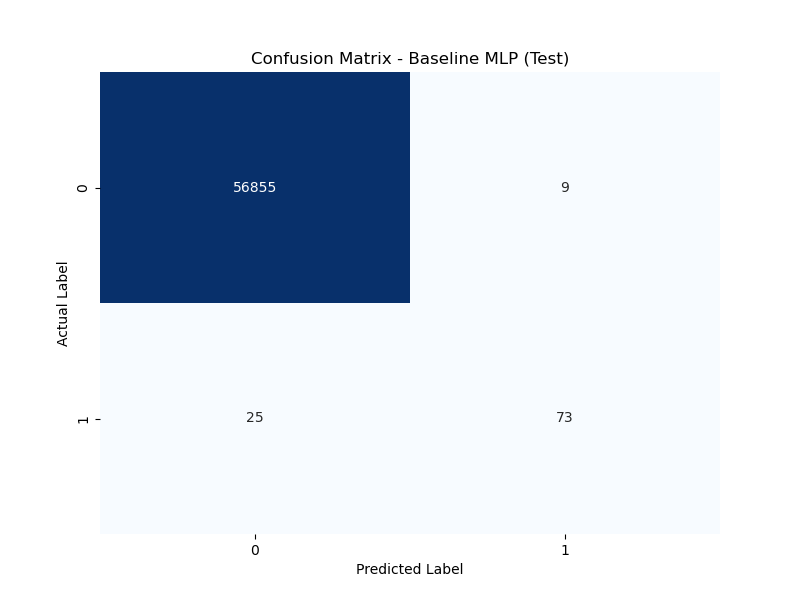

privacy_utility_tradeoff.png


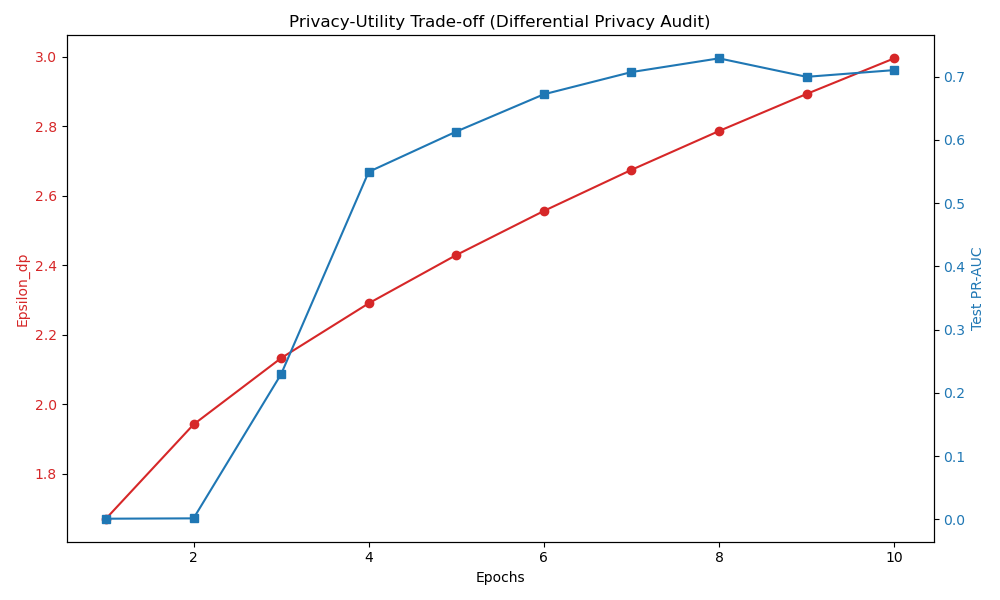

pr_curve.png


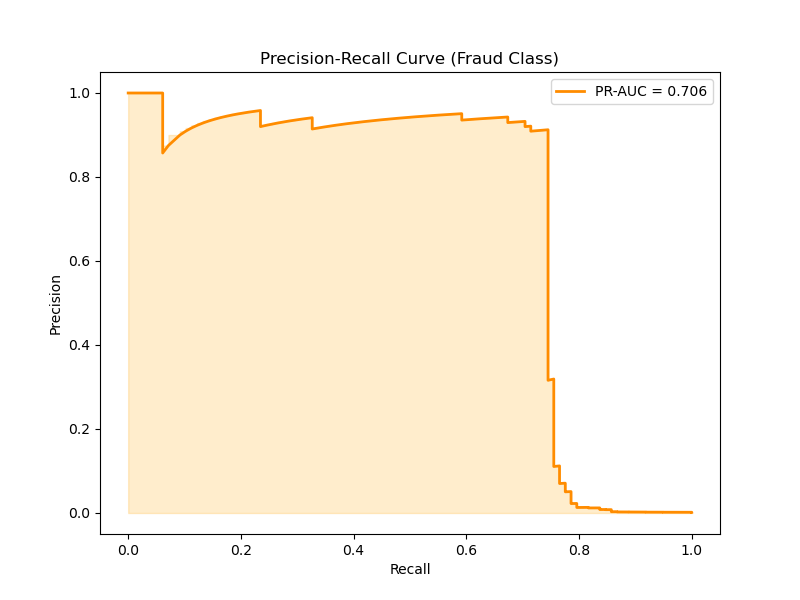

In [132]:
for file in os.listdir("results/dp_model"):
    if file.endswith(".png"):
        print(f"{file}")
        display(Image(filename=os.path.join("results/dp_model", file)))

To understand the impact of our $\epsilon_{dp} = 3$ guarantee, we first compare it directly to our Baseline MLP. At this stage, our focus is exclusively on the trade-off between Privacy and Utility.

The Baseline model tries to learn every small detail to catch as much fraud as possible. When we use DP-SGD, we change the rules. We force the model to ignore specific details so that it cannot remember individual people.

While there is a drop in Recall for the fraud class (0.74) compared to non-private models (0.91), the PR-AUC remains solid at 0.71. This suggests that while the model is more cautious, it still good at identifying which transactions look suspicious.

The drop in recall happens because, in bank data, fraud usually looks like an outlier (unusual or rare behavior). However, Differential Privacy is designed to hide the influence of outliers to protect people's identity. However, Differential Privacy is designed specifically to mask the influence of such outliers to protect individual identity. As a result, the model struggles to distinguish a rare fraud from the random noise injected by the Privacy Engine:  we have traded some of our power to catch fraud for a mathematical guarantee of safety.

We now have a model that is Private, but it is still vulnerable to adversarial attacks. To fix this, our next step is to study the "Triple Tension". In this phase, we will attempt to keep our $\epsilon_{dp}$ budget under control while simultaneously defending the model against a **$0.1 \epsilon_{adv}$** attack. This will test if a model can be private, robust and useful all at once.


In [133]:
!python -m src.privacy.dp_adv_training 

Starting DP-Adversarial Training
Target Privacy (eps_dp): 3.0 | Attack Strength (eps_adv): 0.1
--------------------------------------------------
Epoch 01 | Test PR-AUC: 0.0009 | Spent epsilon_dp: 1.67
Epoch 02 | Test PR-AUC: 0.0012 | Spent epsilon_dp: 1.94
Epoch 03 | Test PR-AUC: 0.1761 | Spent epsilon_dp: 2.13
Epoch 04 | Test PR-AUC: 0.4342 | Spent epsilon_dp: 2.29
Epoch 05 | Test PR-AUC: 0.5470 | Spent epsilon_dp: 2.43
Epoch 06 | Test PR-AUC: 0.6369 | Spent epsilon_dp: 2.56
Epoch 07 | Test PR-AUC: 0.7073 | Spent epsilon_dp: 2.68
Epoch 08 | Test PR-AUC: 0.7297 | Spent epsilon_dp: 2.79
Epoch 09 | Test PR-AUC: 0.7343 | Spent epsilon_dp: 2.89
Epoch 10 | Test PR-AUC: 0.7370 | Spent epsilon_dp: 3.00
Optimal Threshold: 0.000420

=== DP-Adversarial Model - Final Results ===
Accuracy             : 0.9993328885923949
Precision (weighted) : 0.9993011362161468
Recall (weighted)    : 0.9993328885923949
F1-score (weighted)  : 0.999311170150926
Precision (macro)    : 0.9241988282955822
Recall (mac

c:\Users\charl\anaconda3\Lib\site-packages\opacus\privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
c:\Users\charl\anaconda3\Lib\site-packages\opacus\accountants\analysis\rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


confusion_matrix.png


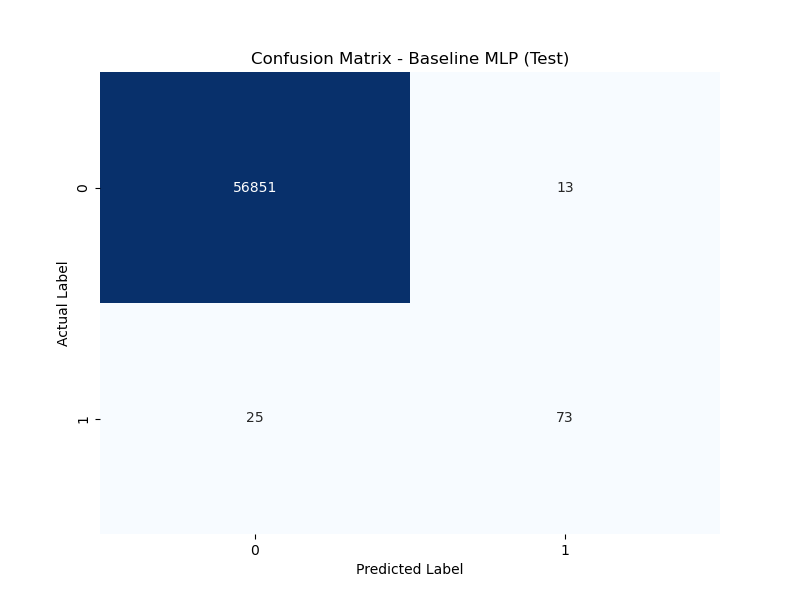

pr_curve.png


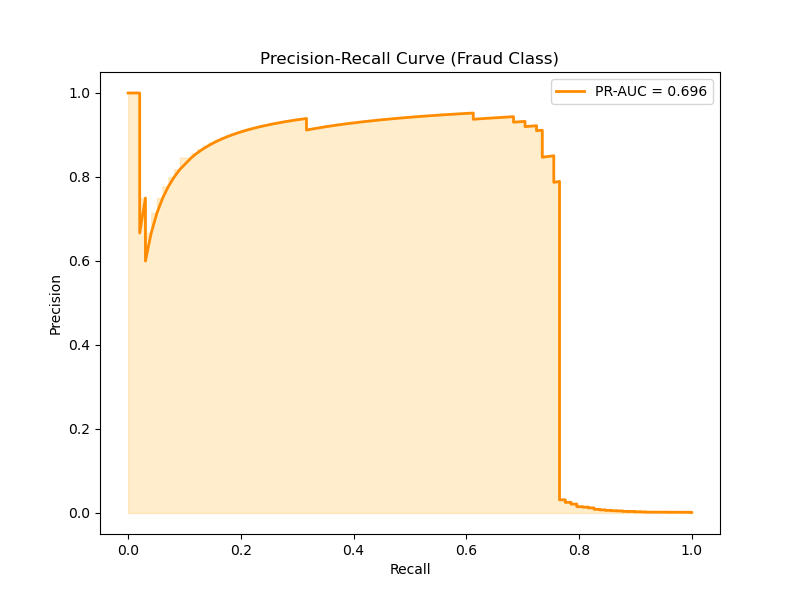

In [138]:
for file in os.listdir("results/dp_adversarial_model"):
    if file.endswith(".png"):
        print(f"{file}")
        display(Image(filename=os.path.join("results/dp_adversarial_model", file)))

Our DP-Adversarial model demonstrates the ultimate trade-off of Trustworthy AI. We maintained a solid ranking ability (PR-AUC 0.69) and the recall stayed at 0.74. 

In [139]:
!python -m src.privacy.mia_attack --dp_mode


Results for DP-Only MLP:
    MIA ROC-AUC: 0.4975
    Attacker Advantage: -0.0058

Results for DP-Adversarial MLP:
    MIA ROC-AUC: 0.4966
    Attacker Advantage: -0.0069

PRIVACY COMPARISON (DP)
DP-Only MLP Advantage: -0.0058
DP-Adversarial MLP Advantage: -0.0069
Difference: -0.0011


The empirical privacy audit (MIA) confirms the strength of our formal DP guarantees. Both private models achieved an MIA ROC-AUC of approximately 0.50, indicating that an attacker cannot distinguish members of the training set from non-members. Crucially, the introduction of adversarial defense in the DP-Adversarial MLP did not result in any measurable increase in privacy leakage compared to the DP-Only model. This demonstrates that we have successfully achieved a 'Privacy-Robustness' synergy.

In [141]:
!python -m src.privacy.triple_tension_study

Attack with Epsilon_dp=2.0 | Epsilon_adv=0.0
Attack with Epsilon_dp=2.0 | Epsilon_adv=0.05
Attack with Epsilon_dp=2.0 | Epsilon_adv=0.1
Attack with Epsilon_dp=2.0 | Epsilon_adv=0.15
Attack with Epsilon_dp=2.0 | Epsilon_adv=0.5
Attack with Epsilon_dp=4.0 | Epsilon_adv=0.0
Attack with Epsilon_dp=4.0 | Epsilon_adv=0.05
Attack with Epsilon_dp=4.0 | Epsilon_adv=0.1
Attack with Epsilon_dp=4.0 | Epsilon_adv=0.15
Attack with Epsilon_dp=4.0 | Epsilon_adv=0.5
Attack with Epsilon_dp=8.0 | Epsilon_adv=0.0
Attack with Epsilon_dp=8.0 | Epsilon_adv=0.05
Attack with Epsilon_dp=8.0 | Epsilon_adv=0.1
Attack with Epsilon_dp=8.0 | Epsilon_adv=0.15
Attack with Epsilon_dp=8.0 | Epsilon_adv=0.5
Attack with Epsilon_dp=16.0 | Epsilon_adv=0.0
Attack with Epsilon_dp=16.0 | Epsilon_adv=0.05
Attack with Epsilon_dp=16.0 | Epsilon_adv=0.1
Attack with Epsilon_dp=16.0 | Epsilon_adv=0.15
Attack with Epsilon_dp=16.0 | Epsilon_adv=0.5
Attack with Epsilon_dp=64.0 | Epsilon_adv=0.0
Attack with Epsilon_dp=64.0 | Epsilon_adv

c:\Users\charl\anaconda3\Lib\site-packages\opacus\privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
c:\Users\charl\anaconda3\Lib\site-packages\opacus\accountants\analysis\rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
c:\Users\charl\anaconda3\Lib\site-packages\opacus\privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
c:\Users\charl\anaconda3\Lib\site-packages\opacus\accountants\analysis\rdp.py:332: UserWarning: Optimal order is the largest alph

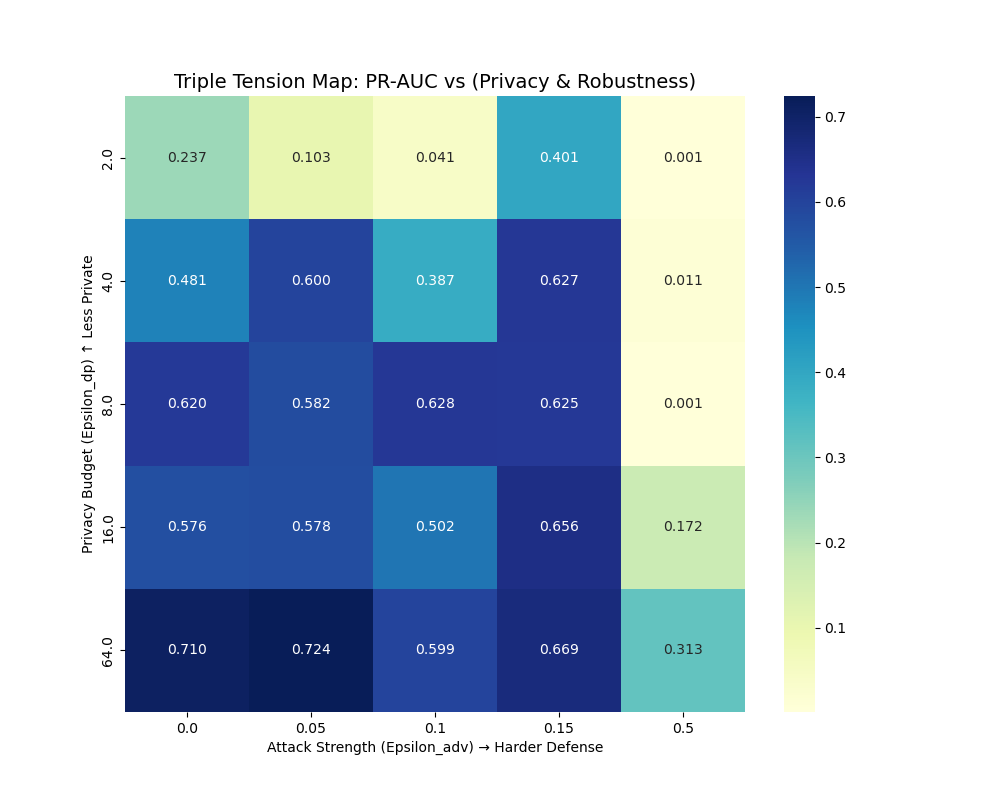

In [145]:
display(Image(filename='results/dp_adversarial_model/triple_tension_heatmap.png'))

This heatmap illustrates the trade-off between Privacy and Rpbustness (5 epochs) : we cannot add excessive noise to protect identity without simultaneously creating security holes that an attacker can exploit

## Fairness & Bias Assessment (Ethics)

Having navigated the Triple Tension between utility, privacy and robustness, we now address the final pillar of Trustworthy AI: Fairness. A high-performing and robust model is only truly reliable if it guarantees the absence of discrimination across user groups. This section is dedicated to a rigorous audit of systemic biases within our fraud detector. We first identify the sources of these disparities, whether they are rooted in historical data imbalances or amplified by our technical constraints, such as the noise introduced by Differential Privacy. We then implement a targeted mitigation strategy to alleviate these biases, followed by an analysis of the evolving sources of discrimination. This comprehensive approach aims to demonstrate that a model can be mathematically private and technically robust while remaining ethically aligned and equitable for all users.

### Assessment

Since the Credit Card Fraud dataset is anonymized (features $V_1$ to $V_{28}$ are PCA components), it doesn't contain explicit protected attributes like "Race" or "Gender." To overcome this limitation and provide a meaningful assessment of algorithmic bias, we will utilize the transaction "Amount" as a proxy sensitive attribute. Specifically, we set the threshold at the 75th percentile ($Q_3 \approx 77.13$), categorizing transactions into "High-Value" (top 25%) and "Low-Value" (bottom 75%) groups. This allows us to investigate whether our model introduces systemic disparities between different socio-economic spending profiles, ensuring that our fraud detection system doesn't just identify fraudulent behavior, but does so equitably, without unfairly flagging specific economic demographics.

The following metrics are used to audit the disparities between Group 0 (Low-Value Transactions) and Group 1 (High-Value Transactions) : 
* **Statistical Parity Difference (SPD)**: This calculates the gap in selection rates between groups ($P(\hat{Y}=1 | G=0) - P(\hat{Y}=1 | G=1)$) to determine if one demographic is flagged as fraudulent more frequently than the other, regardless of actual fraud occurrences. A SPD near 0  means that the model is fair.
* **Equal Opportunity Difference (EOD)**: This focuses on the difference in True Positive Rates ($TPR_{G=0} - TPR_{G=1}$), ensuring the model is equally effective at detecting actual fraudulent behavior across both spending profiles and doesn't "miss" more fraud in one group due to privacy noise. A EOD near 0 means that is fair.
* **Disparate Impact (DI)**: This represents the ratio of selection rates ($\frac{P(\hat{Y}=1 | G=1)}{P(\hat{Y}=1 | G=0)}$), where the ideal value of 1 indicates that both groups are treated with perfect parity by the algorithm, while a result below the "80% rule" (0.8) indicates significant discrimination against the minority and conversely, a score above 1.25 reveals over-targeting.


In [147]:
!python -m src.biais.biais_assessment  --model-path "results/baseline_model/mlp_baseline.pt" --scaler-path "results/baseline_model/scaler.joblib" --name "Baseline"
!python -m src.biais.biais_assessment  --model-path "results/adversarial_model/adversarial_mlp.pt" --scaler-path "results/adversarial_model/scaler.joblib" --name "Adversarial"
!python -m src.biais.biais_assessment  --model-path "results/dp_model/dp_model.pt" --scaler-path "results/dp_model/scaler.joblib" --name "DP-Only" --threshold 0.003109
!python -m src.biais.biais_assessment  --model-path "results/dp_adversarial_model/dp_adv_model.pt" --scaler-path "results/dp_adversarial_model/scaler.joblib" --name "DP-Adversarial" --threshold 0.000420


Fairness Metrics for Baseline:
SPD        |  -0.001325
EOD        |  -0.001399
DI         |   1.062697

Fairness Metrics for Adversarial:
SPD        |   0.002418
EOD        |  -0.016317
DI         |   0.897621

Fairness Metrics for DP-Only:
SPD        |  -0.001068
EOD        |  -0.156177
DI         |   1.911132

Fairness Metrics for DP-Adversarial:
SPD        |  -0.000974
EOD        |  -0.156177
DI         |   1.769567


The audit reveals that securing confidentiality and robustness leads to ethical compromise :

- Baseline Model: With a DI of 1.06 and an EOD near 0, this model is almost perfect. treating both High-Value and Low-Value users with nearly identical accuracy and flagging rates.
- Adversarial Model: We observe the first shift here. The DI drops to 0.89. While still within the regulatory 80% threshold, making the model robust against perturbations begins to make it slightly more "suspicious" of minority spending patterns.
- DP-Only Model and DP-Adversarial Model : The introduction of Differential Privacy causes a dramatic shift. The DI jumps to 1.9 and 1.77 respectively and the EOD drops to -0.16. This indicates that the noise injected to protect individual privacy is washing out the patterns of the minority group, causing the model to lose confidence and over-flag these transactions.

This disparity stems from the inherent technical nature of our security mechanisms:
- Signal-to-Noise Ratio (SNR) Imbalance: Differential Privacy works by adding noise to gradients. Because "High-Value" transactions are a minority group (the top 25%), their statistical signal is much thinner than the majority. The DP noise drowns out their unique features, while the majority group has enough data points to average out the noise.
- Gradient Clipping : To protect individual privacy, we bound the influence of outliers by clipping gradients. However, high-value transactions often generate strong gradients. By clipping them, we effectively mute the voice of these users during training, forcing the model to ignore the nuances of their behavior.
- Conservative Strategy : The privacy noise and adversarial pressure makes the model uncertain. Because the training process heavily penalizes False Negatives, it adopts a defensive rule: when in doubt, it assume it’s fraud. Because high-value transactions are rarer and harder to learn under these constraints, the model plays it safe"by flagging them more often. This explains the surge in DI and the crash in EOD: the model is flagging more people but catching fewer actual frauds.

Our findings prove that maximizing privacy and robustness comes with a hidden ethical cost. By prioritizing security, we inadvertently created a system that is almost 2 times more likely to target high-spending customers unfairly. This "Fairness Gap" represents a significant operational risk. To rectify this, we must implement a Mitigation Strategy.

### Mitigation: Reweighing

To counteract the ethical compromise introduced by robustness and confidentiality, we implement a Fairness-Aware Re-weighting strategy. The goal is to move beyond global accuracy and force the model to distribute its learning effort equitably across all spending profiles, ensuring that privacy constraints do not come at the expense of social equity.

Instead of treating every transaction as equally important, we calculate a specific weight $W$ for each sample based on the intersection of its Group ($G \in \{0, 1\}$) and its Class ($Y \in \{0, 1\}$). Unlike a standard `pos_weight`, which only addresses the global imbalance between fraud and normal transactions, this approach balances the specific distribution within each socio-economic group to prevent the model from ignoring the unique features of the minority demographic.

We apply the following formula to balance the model's "attention budget":
$$W_{g,y} = \frac{N_{total}}{4 \times N_{group=g, class=y}}$$

By using these weights within a `WeightedRandomSampler`, we ensure that during every training batch Minority Fraud cases (High-Value + Fraud) are shown to the model more frequently, compensating for their statistical rarity. This frequency directly counteracts the "Muting Effect" of gradient clipping by amplifying these rare signals, allowing the model to learn from them despite the injected privacy noise. Ultimately, precision is restored as the model is compelled to learn the specific nuances of high-value transactions rather than defaulting to a "flag-everything" defensive strategy.




In [155]:
!python -m src.biais.mitigation

Training Mitigated Model | DP=3.0 | Adv=0.1
Epoch 01 | train loss: 8.15070 | val PR-AUC: 0.0009
Epoch 02 | train loss: 12.65073 | val PR-AUC: 0.0009
Epoch 03 | train loss: 8.95720 | val PR-AUC: 0.0011
Epoch 04 | train loss: 9.18145 | val PR-AUC: 0.0664
Epoch 05 | train loss: 8.23652 | val PR-AUC: 0.2129
Epoch 06 | train loss: 6.40097 | val PR-AUC: 0.3585
Epoch 07 | train loss: 6.08062 | val PR-AUC: 0.5096
Epoch 08 | train loss: 5.66935 | val PR-AUC: 0.5932
Epoch 09 | train loss: 4.85561 | val PR-AUC: 0.6029
Epoch 10 | train loss: 5.48702 | val PR-AUC: 0.6021

Calibrating threshold...
Optimal Threshold: 0.003729

=== Mitigated Model (DP+Adv+Fairness) - Test Set ===
Accuracy             : 0.9991397773954567
Precision (weighted) : 0.9990809985254108
Recall (weighted)    : 0.9991397773954567
F1-score (weighted)  : 0.9990989931192191
Precision (macro)    : 0.9009444886128958
Recall (macro)       : 0.8314919665108587
F1-score (macro)     : 0.8629130975368553
ROC-AUC              : 0.88872967

c:\Users\charl\anaconda3\Lib\site-packages\opacus\privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
c:\Users\charl\anaconda3\Lib\site-packages\opacus\accountants\analysis\rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


confusion_matrix.png


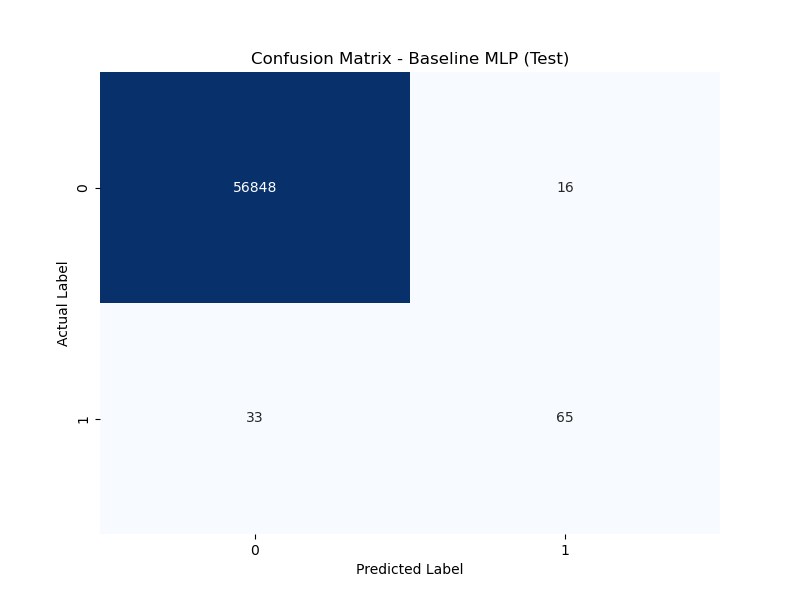

learning_curves.png


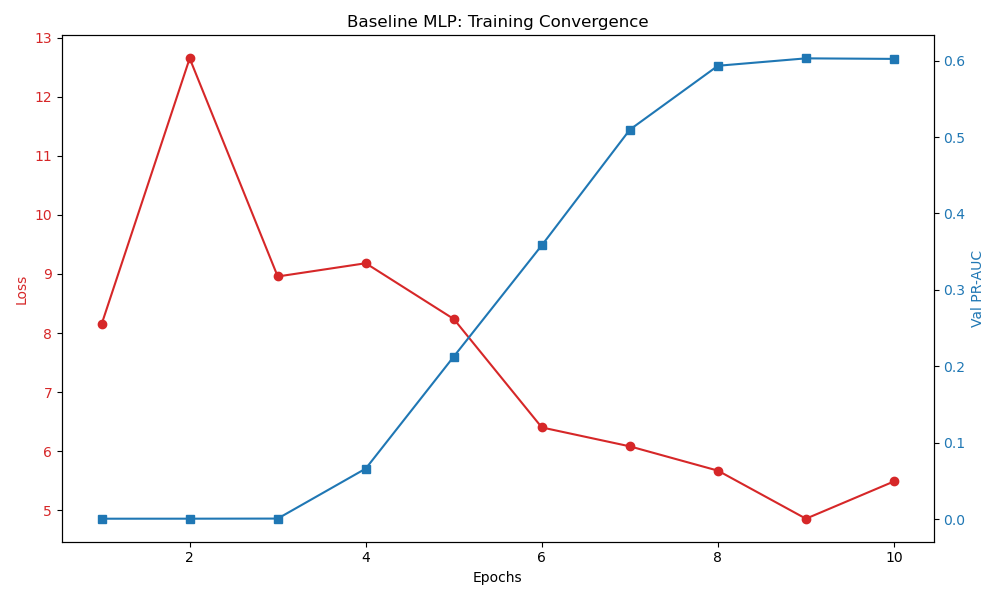

pr_curve.png


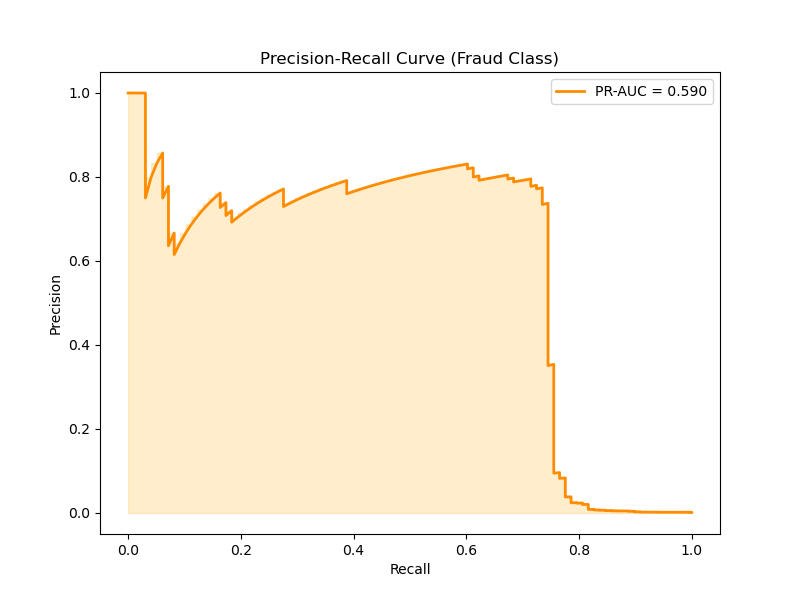

In [156]:
for file in os.listdir("results/mitigated_model"):
    if file.endswith(".png"):
        print(f"{file}")
        display(Image(filename=os.path.join("results", "mitigated_model", file)))

In [157]:
!python -m src.biais.biais_assessment  --model-path "results/mitigated_model/mitigated_mlp.pt" --scaler-path "results/mitigated_model/scaler.joblib" --name "Mitigated" --threshold 0.003729


Fairness Metrics for Mitigated:
SPD        |  -0.000905
EOD        |  -0.142191
DI         |   1.919664


c:\Users\charl\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


While the mitigated model successfully restores operational utility, achieving a respectable PR-AUC of 0.59 and a 66% Recall, the fairness results remain underwhelming, with the Disparate Impact stagnating at 1.92.This outcome explicitly proves the existence of the Triple Tension between Robustness, Privacy and Fairness.

It demonstrates that a privacy budget of $\epsilon_{dp}=3.0$ combined with an adversarial constraint of $\epsilon_{adv}​=0.1$ is too restrictive for demographic parity. At such extreme security levels, the mandatory per-sample gradient clipping required for confidentiality acts as a technical ceiling that neutralizes our fairness re-weighting efforts before they can shift the decision boundary. Ultimately, this result confirms that the "Fairness Gap" is irreducible at $\epsilon_{dp}=3.0$ : the model cannot mathematically satisfy the demands of strict confidentiality and adversarial stability while simultaneously achieving perfect equity. 

### Sources of biais before and after mitigation

1. Sources of Bias Before Mitigation

The primary source of bias in our secure model is not inherent to the raw data alone, but is technically induced by the security layers. A central mechanism of Differential Privacy is per-sample gradient clipping, which is necessary to bound the influence of any individual transaction on the final model. However, high-value transactions often generate gradients with higher magnitudes than the low-value majority.
By clipping these gradients to a fixed maximum norm, the model performs signal flattening, reducing the distinct patterns of the minority group to the same scale as the majority. This diminished signal is subsequently obscured by the injection of Gaussian noise. Because high-value transactions are numerically rare, their specific signal-to-noise ratio is much lower than that of the majority group. Consequently, the DP noise effectively drowns out the patterns of high-amount fraud while leaving the majority group’s patterns intact. This results in a significant spike in Disparate Impact, as the model loses its predictive precision specifically for the high-value group.

Furthermore, adversarial training requires the model to prioritize decision boundary stability. By smoothing the model's response to prevent adversarial exploitation, the system often discards the rare and sharp features associated with high-value fraud, identifying them as fragile outliers. These combined security layers lead to a substantial increase in disparate impact.

2. Sources of Bias After Mitigation

Our mitigation strategy addresses these biases by introducing a Fairness Re-weighting mechanism. By applying higher weights to the loss function for the sensitive minority group, the system attempts to amplify their gradients before the clipping and noise stages. This is intended to ensure that the signal for high-value transactions remains strong enough to be learned despite the privacy-preserving constraints. Additionally, through optimal threshold search on a validation set, the model's decision criteria were adjusted to account for probability compression, successfully restoring operational utility (Recall of 0.66 and PR-AUC of 0.59).

However, despite these efforts, the Disparate Impact stagnated at 1.92. This outcome explicitly proves the existence of an irreducible Triple Tension between Robustness, Privacy and Fairness.

The results demonstrate that a privacy budget of $\epsilon_{dp} = 3.0$ is too restrictive to allow for demographic parity. At such a high noise level,Even if we increase the weights for the minority group, the clipping mechanism "censors" these boosted gradients back down to the maximum norm to maintain the privacy guarantee. The model cannot mathematically satisfy the demands of extreme confidentiality and adversarial stability while simultaneously achieving perfect equity. The cost of high security is, in this case, a persistent bias against the minority group.

## Final Outcomes & Limitations

This project successfully demonstrates the technical feasibility of transforming a standard, vulnerable fraud detection model into a secure system. By integrating Differential Privacy and Adversarial Training, we developed a framework capable of simultaneously defending against data leakage and malicious perturbations.

However, the study also highlights the significant trade-offs inherent in the Triple Tension between utility, privacy, robustness and fairness. As security constraints are compounded, the optimization process becomes increasingly restricted. Ultimately, we reached a point of irreducible bias where the rigid demands of high-level confidentiality and structural stability physically limit the effectiveness of fairness mitigation. This proves that at extreme security levels, absolute equity and absolute protection become mathematically conflicting objectives.

A limitation of this research is the reliance on a single, highly restrictive privacy budget of epsilon 3.0. By keeping this parameter static, the study does not fully explore the sensitivity of the fairness mitigation strategy across the broader privacy-fairness spectrum. Conducting a multi-epsilon sensitivity analysis would have allowed for the identification of a specific threshold where the gradient clipping and noise injection become permissive enough for intersectional re-weighting to effectively reduce bias. Without such a comparative study, it remains unclear whether the observed fairness irreducibility is a permanent trait of the model architecture or a localized consequence of the extreme confidentiality constraints selected for this specific implementation. Exploring this range would have provided a more precise mapping of the Pareto frontier, helping to determine the exact point at which security ceases to act as an impassable barrier to demographic parity.